1️⃣ Resize images and split dataset into train, validation and test. 

In [4]:
import os
import shutil
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# Paths
no_path = "dataset/no"
yes_path = "dataset/yes"

output_base = "dataset_processed"
os.makedirs(output_base, exist_ok=True)

# Folders for splits
splits = ["train", "val", "test"]
classes = ["no", "yes"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)

# Function to resize and save images
def resize_and_save(files, src_folder, dest_folder, size=(224,224)):
    for file in files:
        img = Image.open(os.path.join(src_folder, file)).convert("RGB")
        img = img.resize(size)
        img.save(os.path.join(dest_folder, file))

# Split per class
for cls, path in zip(classes, [no_path, yes_path]):
    all_files = sorted(os.listdir(path))
    
    # Split into train/val/test
    train_files, test_files = train_test_split(all_files, test_size=800, random_state=42)
    val_files, test_files_final = train_test_split(test_files, test_size=0.8, random_state=42)  
    # This gives roughly: train=500, val=200, test=800
    
    # Resize and save
    resize_and_save(train_files, path, os.path.join(output_base, "train", cls))
    resize_and_save(val_files, path, os.path.join(output_base, "val", cls))
    resize_and_save(test_files_final, path, os.path.join(output_base, "test", cls))

print("Preprocessing done! Dataset is ready for CNN and ResNet.")


Preprocessing done! Dataset is ready for CNN and ResNet.


2️⃣ Display Sample Images After Preprocessing

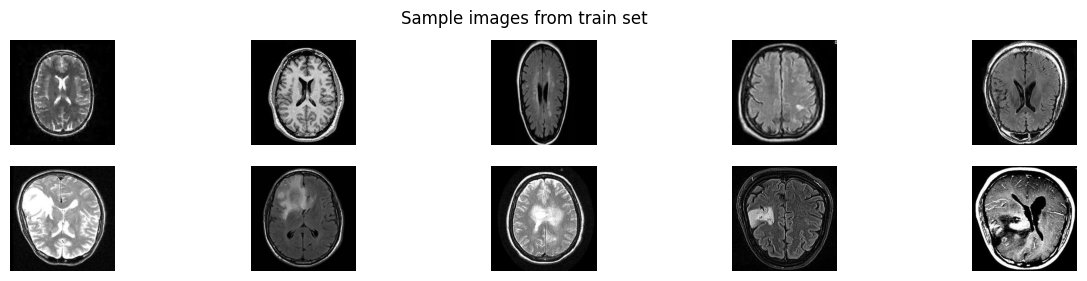

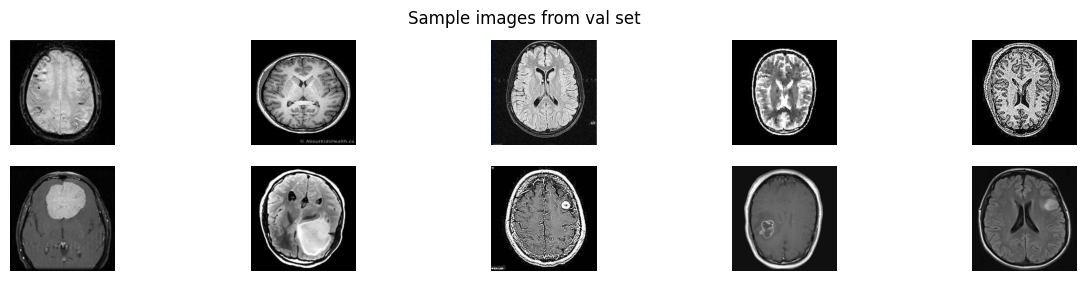

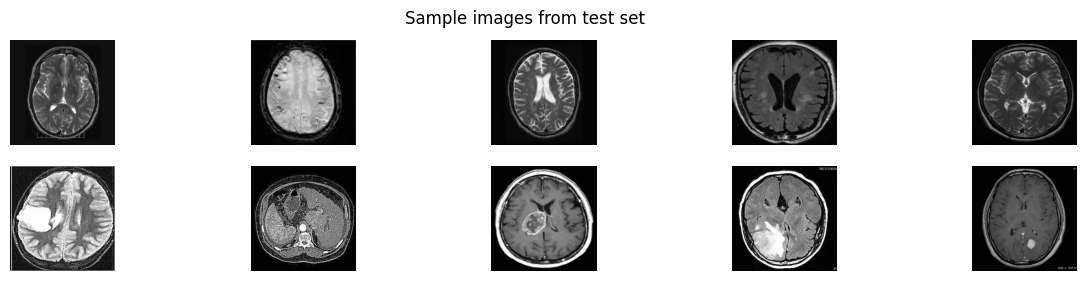

In [10]:
import matplotlib.pyplot as plt
import os

def show_sample_images(base_path, split="train", n=5):
    plt.figure(figsize=(15,3))
    for i, cls in enumerate(["no", "yes"]):
        files = np.random.choice(os.listdir(os.path.join(base_path, split, cls)), n, replace=False)
        for j, file in enumerate(files):
            img = Image.open(os.path.join(base_path, split, cls, file))
            plt.subplot(2, n, i*n + j + 1)
            plt.imshow(img)
            plt.axis("off")
            if j == 0:
                plt.ylabel(cls, fontsize=12)
    plt.suptitle(f"Sample images from {split} set")
    plt.show()

# Display train samples
show_sample_images("dataset_processed", "train")

# Display validation samples
show_sample_images("dataset_processed", "val")

# Display test samples
show_sample_images("dataset_processed", "test")

3️⃣ Pixel Intensity Stats After Preprocessing

In [8]:
base_path = "dataset_processed"

def pixel_stats(folder, n_samples=100):
    pixels = []
    files = np.random.choice(os.listdir(folder), n_samples, replace=False)
    for file in files:
        img = np.array(Image.open(os.path.join(folder, file)).convert("L"))
        pixels.extend(img.flatten())
    return np.mean(pixels), np.std(pixels), np.min(pixels), np.max(pixels)

for split in ["train", "val", "test"]:
    for cls in ["no", "yes"]:
        folder = os.path.join(base_path, split, cls)
        mean, std, min_val, max_val = pixel_stats(folder)
        print(f"{split}-{cls}: mean={mean:.2f}, std={std:.2f}, min={min_val}, max={max_val}")


train-no: mean=60.05, std=66.63, min=0, max=255
train-yes: mean=81.45, std=74.49, min=0, max=255
val-no: mean=63.78, std=67.70, min=0, max=255
val-yes: mean=83.60, std=76.25, min=0, max=255
test-no: mean=58.40, std=63.83, min=0, max=255
test-yes: mean=80.67, std=74.98, min=0, max=255


Pixel intensity analysis showed that tumor-present (‘yes’) images had slightly higher mean intensity values (≈80) compared to tumor-absent (‘no’) images (≈60), indicating hyperintense tumor regions. Standard deviations (≈65–75) confirmed good contrast across all splits, and full pixel ranges (0–255) indicated no clipping or corruption in the data.